# Necessary Imports

In [1]:
import pandas as pd
import numpy as np
import os
import random
import torch
import json
import math
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
from torch import nn, optim, Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from typing import Callable, Dict, Iterator, Tuple
from torch_sparse import SparseTensor
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from dataclasses import dataclass, asdict
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData
from nltk import word_tokenize
from scipy.sparse import csgraph
from torch_scatter import scatter_mean

In [2]:
sns.set_theme(style='darkgrid', palette='husl')

In [3]:
tqdm.pandas()

# Reproducibility

In [4]:
SEED = 42

In [5]:
def seed_everything(seed: int) -> None:    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [6]:
seed_everything(SEED)

In [7]:
TRAIN = False

# Load The Data

In [8]:
data_url = os.path.join("data_download", "data", 'data.raw.jsonl')

In [9]:
records = []
i = 0

with open(data_url, 'r') as f:
    for line in f:
        try:
            records.append(json.loads(line.rstrip("\n")))
        except:
            pass
        i += 1

In [10]:
df = pd.DataFrame(records)
# df = df[df["teams"].apply(lambda x : "LS2N" in x)]

In [11]:
df['main_venues'] = df['venue'].apply(lambda x : [venue.split('.')[0] for venue in x])
mask = df['main_venues'].apply(lambda x : 'info' in x)
df = df[mask]
len(df)

108236

In [12]:
df.head()

,id,title,abstract,keywords,authors,venue,date,main_venues
8,5172589,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08T00:00:00Z,[info]
15,5308758,Designing Restorative Small Urban Green Spaces...,This interdisciplinary thesis explored the imp...,"[subjective preference, cognitive restoration,...",[Pooria Baniadam],"[shs.archi, info.info-gr, sde.ie]",2025-05-26T00:00:00Z,"[shs, info, sde]"
17,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[soft mobility, d city model, sky view image, ...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28T00:00:00Z,[info]
19,5269259,Luminous Atmospheres 360: Comparing VR HMDs an...,This paper studies the potential of VR HMDs to...,"[education, luminous atmospheres, virtual real...","[Michèle Atié, Céline Drozd, Toinon Vigier, Da...","[shs.archi, info.info-gr, info.info-hc]",2025-03-08T00:00:00Z,"[shs, info, info]"
31,4774024,Efficient matrix algebra encoding for urban so...,Conducting a detailed assessment of solar irra...,"[ground level assessment of solar irradiation,...","[Ziang Cui, Thomas Leduc]","[info.info-mo, sde.es, shs.archi]",2024-11-07T00:00:00Z,"[info, sde, shs]"


# Take a look at the data

In [13]:
df.head()

,id,title,abstract,keywords,authors,venue,date,main_venues
8,5172589,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08T00:00:00Z,[info]
15,5308758,Designing Restorative Small Urban Green Spaces...,This interdisciplinary thesis explored the imp...,"[subjective preference, cognitive restoration,...",[Pooria Baniadam],"[shs.archi, info.info-gr, sde.ie]",2025-05-26T00:00:00Z,"[shs, info, sde]"
17,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[soft mobility, d city model, sky view image, ...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28T00:00:00Z,[info]
19,5269259,Luminous Atmospheres 360: Comparing VR HMDs an...,This paper studies the potential of VR HMDs to...,"[education, luminous atmospheres, virtual real...","[Michèle Atié, Céline Drozd, Toinon Vigier, Da...","[shs.archi, info.info-gr, info.info-hc]",2025-03-08T00:00:00Z,"[shs, info, info]"
31,4774024,Efficient matrix algebra encoding for urban so...,Conducting a detailed assessment of solar irra...,"[ground level assessment of solar irradiation,...","[Ziang Cui, Thomas Leduc]","[info.info-mo, sde.es, shs.archi]",2024-11-07T00:00:00Z,"[info, sde, shs]"


# Pre-processing

- Remove duplicates.
- Remove extermely short abstracts.

In [14]:
tokens_count = df['abstract'].progress_apply(str.split)

  0%|          | 0/108236 [00:00<?, ?it/s]

In [15]:
mask_to_drop = df['id'].duplicated() | df['title'].duplicated() | (df['venue'].apply(len) == 0) | (tokens_count.apply(len) < 20)
# mask_to_drop |= df['venue'].apply(lambda x : [v.split('.')[0] for v in x]).apply(lambda x : 'info' in x)

In [16]:
df = df[~mask_to_drop]

In [17]:
print(len(df))

78944


# Prepare The Data For Training

- Venues

In [18]:
def get_venue(venue : str, cats : list[str], order : int = 1) -> str | None:

    parts = venue.split('.')

    if len(parts) < order or parts[0] not in cats:
        return None
    
    return '.'.join(parts[:order])

In [19]:
def get_venues(venues : list[str], cats : list[str], order : int = 1) -> list[str]:

    venues = [get_venue(venue, cats, order) for venue in venues]
    venues = filter(None, venues)
    venues = list(set(venues))

    return venues

In [20]:
df['venues_2'] = df['venue'].apply(lambda x : get_venues(x, ['info'], 2))
df = df[df['venues_2'].apply(len) != 0]

In [21]:
print(len(df))

71859


In [22]:
venues_count = defaultdict(int)

for idx,row in df.iterrows():
    for venue in row['venues_2']:
        venues_count[venue] += 1

In [23]:
venues = [venue for venue,count in venues_count.items() if count >= 100]
print(len(venues))

55


In [24]:
mask = df['venues_2'].apply(lambda x : any([venue in x for venue in venues]))
df = df[mask]

In [25]:
labels = []

for i,(idx, row) in enumerate(df.iterrows()):
    for venue in row['venues_2']:
        if venue in venues:
            labels.append((i, venues.index(venue)))

In [26]:
labels = torch.tensor(labels)
labels = SparseTensor(row=labels[:,0], col=labels[:, 1]).to_dense()

- Compute Articles Embeddings

In [27]:
model_name = "all-MiniLM-L6-v2"
sent_trans = SentenceTransformer(model_name) # all-mpnet-base-v2, all-MiniLM-L6-v2

In [28]:
articles_embeddings = torch.from_numpy(
    sent_trans.encode(
        sentences=df['abstract'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        device='cuda',
        normalize_embeddings=True,
    )
)

Batches:   0%|          | 0/1123 [00:00<?, ?it/s]

In [29]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Data Splitting

In [30]:
articles_embeddings.size(), labels.size()

(torch.Size([71856, 384]), torch.Size([71856, 55]))

In [31]:
indices = torch.arange(articles_embeddings.size(0))
x_train, x_test, y_train, y_test, train_indices, test_indices = train_test_split(articles_embeddings, labels, indices, test_size=0.1)

In [32]:
np.save('embeddings.npy', x_test.numpy())

# The Model For Finetuning

In [ ]:
class MLP(nn.Module):

    def __init__(self, 
        in_dim : int,
        hidden_dims : list[int],
        out_dim : int,
        hidden_act : Callable[[Tensor], Tensor] = F.relu,
        out_act : Callable[[Tensor], Tensor] = nn.Identity(),
        norm : bool = False
    ) -> None:
        super().__init__()

        self.in_dim = in_dim
        self.hidden_dims = hidden_dims
        self.out_dim = out_dim
        self.hidden_act = hidden_act
        self.out_act = out_act

        self.layers = nn.ModuleList()

        self.layers.append(nn.Sequential(
            nn.Linear(in_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]) if norm else nn.Identity()
        ))

        for input_dim, output_dim in zip(hidden_dims[:-1], hidden_dims[1:]):

            self.layers.append(nn.Sequential(
                nn.Linear(input_dim, output_dim),
                nn.BatchNorm1d(output_dim) if norm else nn.Identity()
            ))
        self.out = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x : Tensor) -> Tensor:

        for layer in self.layers:
            x = self.hidden_act(layer(x))

        x = self.out(x)
        x = self.out_act(x)

        return x

# Training

In [ ]:
@dataclass
class Config:

    ### Mode Config
    in_dim : int
    hidden_dims : list[int]
    out_dim : int
    hidden_act : Callable[[Tensor], Tensor] = F.relu
    out_act : Callable[[Tensor], Tensor] = F.sigmoid
    norm : bool = False

    ### Training Hyper-parameters
    batch_size : int = 64
    lr : float = 1e-3
    weight_decay : float = 0.0
    num_epochs : int = 20
    num_negatives : int = 3

    ### Data Loading
    num_workers : int = 4
    prefetch_factor : int = 2

    ### Device
    device : str = 'cuda' if torch.cuda.is_available() else 'cpu'

    ### Loggin 
    log_every : int = 1

In [ ]:
def train_iteration(
    model : MLP,
    optimizer : optim.Optimizer,
    batch : Tuple[Tensor, Tensor],
    phase : str,
    device : str
) -> Dict[str, float]:
    
    is_training = phase == 'train'
    model.train(is_training)

    with torch.set_grad_enabled(is_training):
        
        ### Move Data To The Right Device
        x, y = batch
        x, y = x.to(device), y.to(device)
        # y = y.float()

        ### Forward pass
        y_hat = model.forward(x)

        ### Loss
        f = y.mean().detach().cpu().item()
        weight = (1 - y) * f + y * (1 - f)
        loss = F.binary_cross_entropy(y_hat, y, weight=weight)

    ### Backward pass
    if is_training:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ### Metrics
    y_hat = y_hat.detach().cpu().numpy().reshape(-1)
    y_hard = np.int32(y_hat >= 0.5).reshape(-1)
    y = y.detach().cpu().numpy().reshape(-1)

    acc = accuracy_score(y_true=y, y_pred=y_hard)
    f1 = f1_score(y_true=y, y_pred=y_hard, average="macro", zero_division=0.0)

    return {
        "Loss" : loss.item(),
        "Accuracy" : acc,
        "Macro-F1 Score" : f1,
    }

In [ ]:
def train(
    train_dataset : Tuple[Tensor, Tensor],
    test_dataset : Tuple[Tensor, Tensor],
    config : Config
) -> Tuple[MLP, pd.DataFrame]:

    ### Create The Model & Optimize
    model = MLP(
        in_dim=config.in_dim,
        hidden_dims=config.hidden_dims,
        out_dim=config.out_dim,
        hidden_act=config.hidden_act,
        out_act=config.out_act,
        norm=config.norm
    ).to(config.device)

    optimizer = optim.AdamW(params=model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    ### Create Loaders
    train_loader = DataLoader(
        dataset=TensorDataset(*train_dataset), 
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
    )

    test_loader = DataLoader(
        dataset=TensorDataset(*test_dataset), 
        batch_size=config.batch_size, 
        shuffle=False,
        drop_last=False,
    )

    ### Initialize History
    history = []

    ### Training Loop
    for epoch in range(config.num_epochs):

        for phase in ['train', 'test']:

            loader = train_loader if phase == 'train' else test_loader
            running_values = defaultdict(float)
            
            for i,batch in tqdm(enumerate(loader), total=len(loader)):

                results = train_iteration(model, optimizer, batch, phase, config.device)   

                for metric_name, metric_value in results.items():
                    running_values[metric_name] += metric_value / len(loader)

                results['Epoch'] = epoch 
                results['Iteration'] = i
                results['Phase'] = phase

                history.append(results)

            if (epoch+1) % config.log_every == 0:
                msg = f"Epoch : {(epoch+1)}/{config.num_epochs} | Phase : {phase.upper()} | "
                msg += " | ".join([f"{key}={value}" for key, value in running_values.items()])
                print(msg)

    return model, pd.DataFrame(history)

In [ ]:
config = Config(
    in_dim=x_train.size(-1),
    hidden_dims=[x_train.size(-1) // 2] * 2,
    out_dim=y_train.size(-1),
    hidden_act=F.selu,
    out_act=F.sigmoid,
    norm=True,
    batch_size=64,
    lr=1e-4,
    weight_decay=1e-3,
    num_epochs=10,
    log_every=1,
    num_negatives=1,
    device='cpu'
)

In [ ]:
model, history = train(
    (x_train, y_train),
    (x_test, y_test),
    config=config
)

  0%|          | 0/1010 [00:00<?, ?it/s]

Epoch : 1/10 | Phase : TRAIN | Loss=0.02273806797358956 | Accuracy=0.6311245499549946 | Macro-F1 Score=0.43988076376223484


  0%|          | 0/113 [00:00<?, ?it/s]

Epoch : 1/10 | Phase : TEST | Loss=0.019977374496845016 | Accuracy=0.7403450992223116 | Macro-F1 Score=0.5006531448410473


  0%|          | 0/1010 [00:00<?, ?it/s]

...

Epoch : 9/10 | Phase : TEST | Loss=0.013223609392555942 | Accuracy=0.8967085121122728 | Macro-F1 Score=0.6230443183376906


  0%|          | 0/1010 [00:00<?, ?it/s]

Epoch : 10/10 | Phase : TRAIN | Loss=0.011551504725092431 | Accuracy=0.8981888501350132 | Macro-F1 Score=0.6270976787387742


  0%|          | 0/113 [00:00<?, ?it/s]

Epoch : 10/10 | Phase : TEST | Loss=0.013229686667961352 | Accuracy=0.900006145526057 | Macro-F1 Score=0.626817579535646


# Evaluation : Learning Curves

In [ ]:
history_summary = history.drop(columns=['Iteration']).groupby(['Epoch','Phase']).mean().reset_index()

<Axes: xlabel='Epoch', ylabel='Loss'>

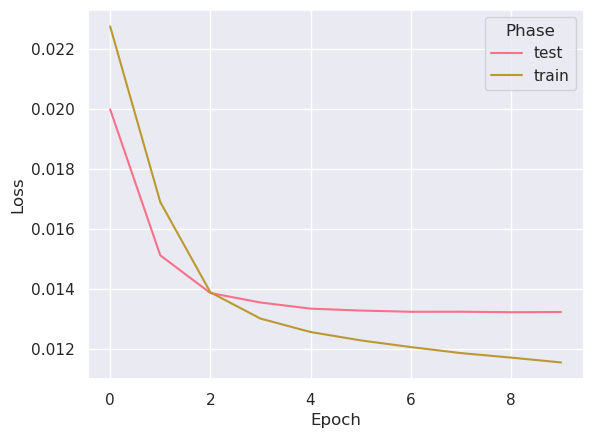

In [ ]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Loss',
    hue='Phase'
)

<Axes: xlabel='Epoch', ylabel='Accuracy'>

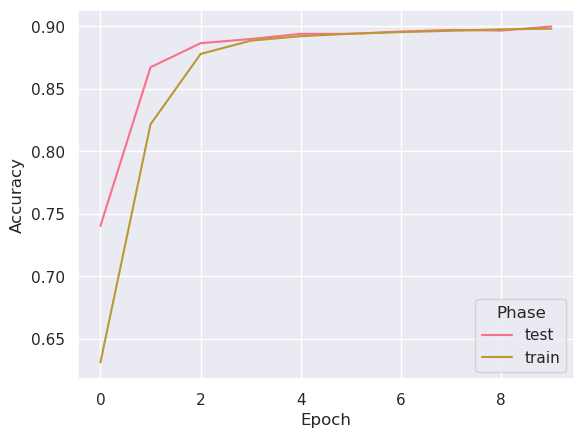

In [ ]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Accuracy',
    hue='Phase'
)

<Axes: xlabel='Epoch', ylabel='Macro-F1 Score'>

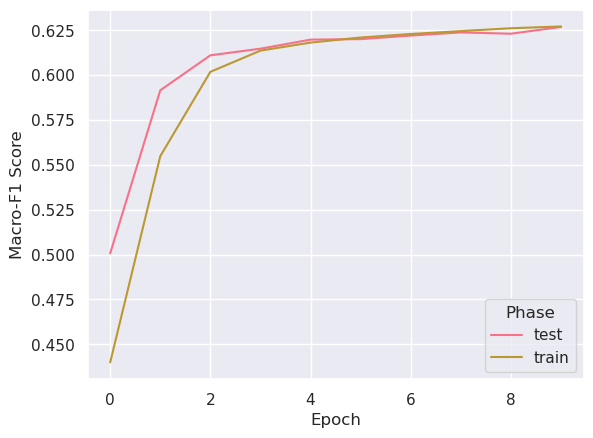

In [ ]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Macro-F1 Score',
    hue='Phase'
)

# Evaluation : More

In [ ]:
def get_embeddings(
    x : Tensor,
    model : nn.Module,
    batch_size : int,
    device : str
) -> Tensor:
    
    model.to(device).eval()
    loader = DataLoader(dataset=TensorDataset(x), batch_size=batch_size, shuffle=False)
    
    Y = []
    
    with torch.inference_mode():

        for batch in tqdm(loader):
            batch = batch[0].to(device)
            embeddings = model.forward(batch)
            embeddings = embeddings.detach().cpu()
            Y.append(embeddings)

    Y = torch.cat(Y)

    return Y

In [ ]:
y_test_hat = get_embeddings(x_test, model, batch_size=512, device=Config.device)

  0%|          | 0/15 [00:00<?, ?it/s]

# Saving Checkpoint

In [ ]:
conf = asdict(config)
conf['hidden_act'] = conf['hidden_act'].__name__
conf['out_act'] = conf['out_act'].__name__

In [ ]:
checkpoint = {
    "config" : conf,
    "state_dict" : model.state_dict(),
    "venues" : venues,
    "sentence_bert_model" : model_name
}

In [ ]:
torch.save(checkpoint, 'checkpoint.pt')

# Save Scroing Stuff

In [ ]:
torch.save(y_test_hat,'y_test_hat.pt')

In [ ]:
df.iloc[test_indices]['abstract'].to_csv('test.csv', index=False)